In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

In [3]:
df = pd.read_csv(r"C:\Users\shakti\Downloads\sme_business_dataset_final.csv")
df

,Date,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
0,01-01-2025,Service,4327,6878,75,-2551,152,UPI
1,02-01-2025,Wholesale,10004,7303,33,2701,485,UPI
2,03-01-2025,Retail,4931,1851,47,3080,398,UPI
3,04-01-2025,Service,9777,2687,97,7090,320,Card
4,05-01-2025,Service,2197,7833,149,-5636,156,Cash
...,...,...,...,...,...,...,...,...
346,27-12-2025,Wholesale,11827,5777,173,6050,401,Card
347,28-12-2025,Retail,9421,4900,188,4521,248,Cash
348,29-12-2025,Retail,11949,7677,54,4272,357,Cash
349,30-12-2025,Service,6452,7981,82,-1529,466,Net Banking


In [4]:
df.head()

,Date,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
0,01-01-2025,Service,4327,6878,75,-2551,152,UPI
1,02-01-2025,Wholesale,10004,7303,33,2701,485,UPI
2,03-01-2025,Retail,4931,1851,47,3080,398,UPI
3,04-01-2025,Service,9777,2687,97,7090,320,Card
4,05-01-2025,Service,2197,7833,149,-5636,156,Cash


In [5]:
df.tail()


,Date,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
346,27-12-2025,Wholesale,11827,5777,173,6050,401,Card
347,28-12-2025,Retail,9421,4900,188,4521,248,Cash
348,29-12-2025,Retail,11949,7677,54,4272,357,Cash
349,30-12-2025,Service,6452,7981,82,-1529,466,Net Banking
350,31-12-2025,Food,12262,7376,44,4886,473,Card


In [6]:
df.sample(5)

,Date,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
171,21-06-2025,Retail,9806,5964,165,3842,280,Card
207,27-07-2025,Wholesale,11358,8266,174,3092,280,Cash
260,18-09-2025,Retail,3664,5854,119,-2190,179,Cash
89,31-03-2025,Food,7699,6334,152,1365,251,Card
273,01-10-2025,Wholesale,14991,5164,48,9827,450,Card


In [7]:
df.isnull().sum()

Date              0
Business_Type     0
Daily_Sales       0
Expenses          0
Customer_Count    0
Profit            0
Inventory         0
Payment_Mode      0
dtype: int64

In [8]:
columns_to_drop = ["Unnamed: 7", "Unnamed: 8"]
existing_columns = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns, axis=1)

In [9]:
df

,Date,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
0,01-01-2025,Service,4327,6878,75,-2551,152,UPI
1,02-01-2025,Wholesale,10004,7303,33,2701,485,UPI
2,03-01-2025,Retail,4931,1851,47,3080,398,UPI
3,04-01-2025,Service,9777,2687,97,7090,320,Card
4,05-01-2025,Service,2197,7833,149,-5636,156,Cash
...,...,...,...,...,...,...,...,...
346,27-12-2025,Wholesale,11827,5777,173,6050,401,Card
347,28-12-2025,Retail,9421,4900,188,4521,248,Cash
348,29-12-2025,Retail,11949,7677,54,4272,357,Cash
349,30-12-2025,Service,6452,7981,82,-1529,466,Net Banking


In [10]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [11]:
import warnings
warnings.filterwarnings('ignore')

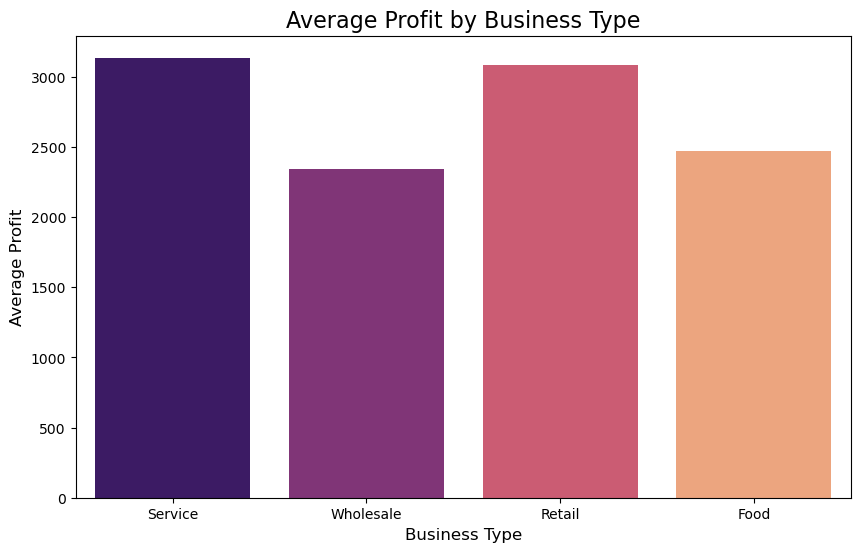

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Business_Type', y='Profit', palette='magma', ci=None)
plt.title('Average Profit by Business Type', fontsize=16)
plt.xlabel('Business Type', fontsize=12)
plt.ylabel('Average Profit', fontsize=12)
plt.show()

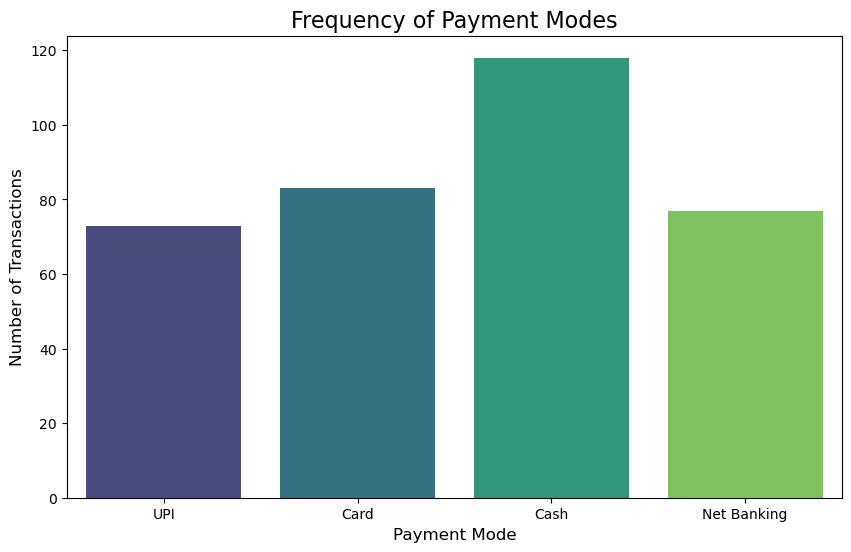

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Payment_Mode', palette='viridis')
plt.title('Frequency of Payment Modes', fontsize=16)
plt.xlabel('Payment Mode', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.show()

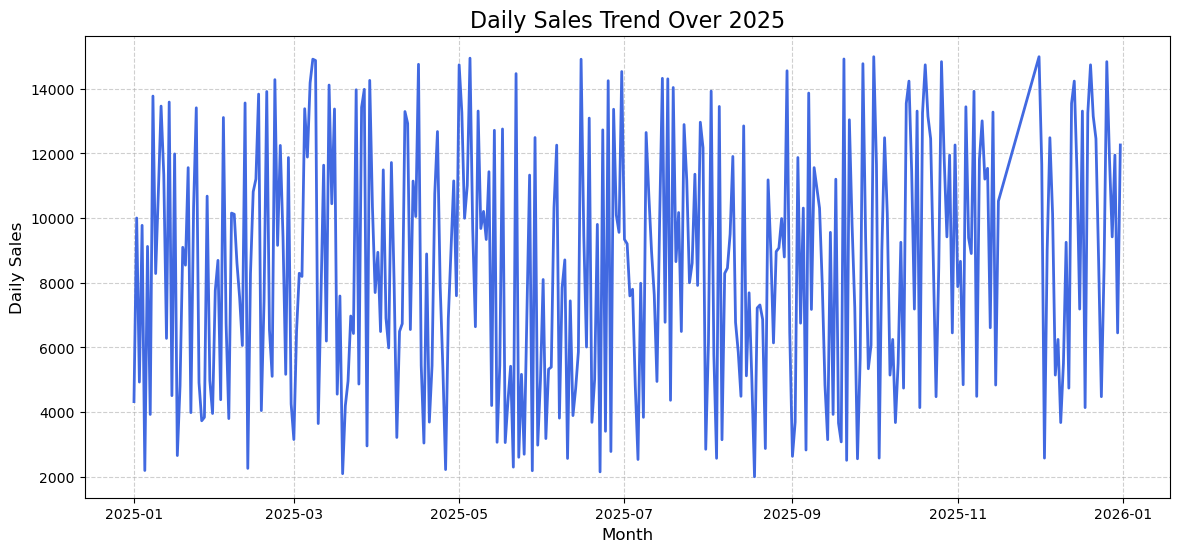

In [14]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Daily_Sales', color='royalblue', linewidth=2)
plt.title('Daily Sales Trend Over 2025', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Daily Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

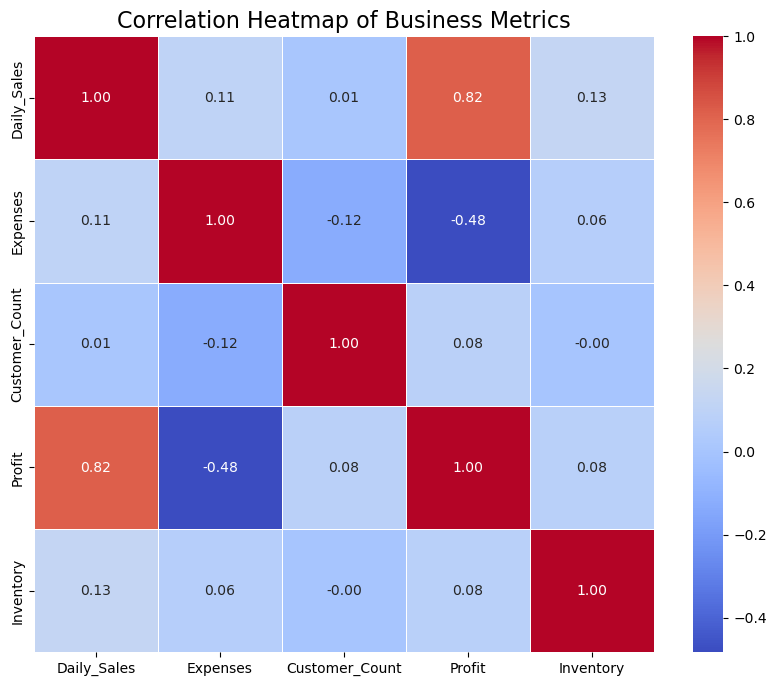

In [15]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Business Metrics', fontsize=16)
plt.show()

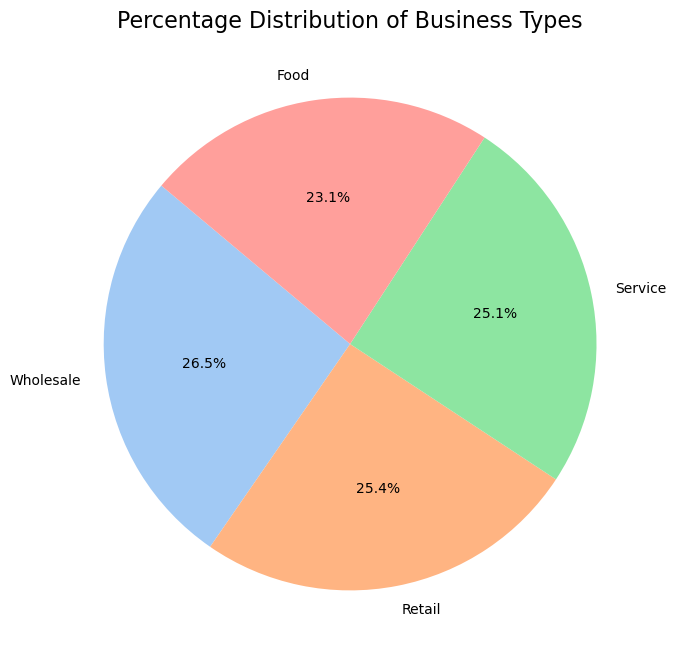

In [16]:
business_counts = df['Business_Type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(business_counts, 
        labels=business_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel'))
plt.title('Percentage Distribution of Business Types', fontsize=16)
plt.show()

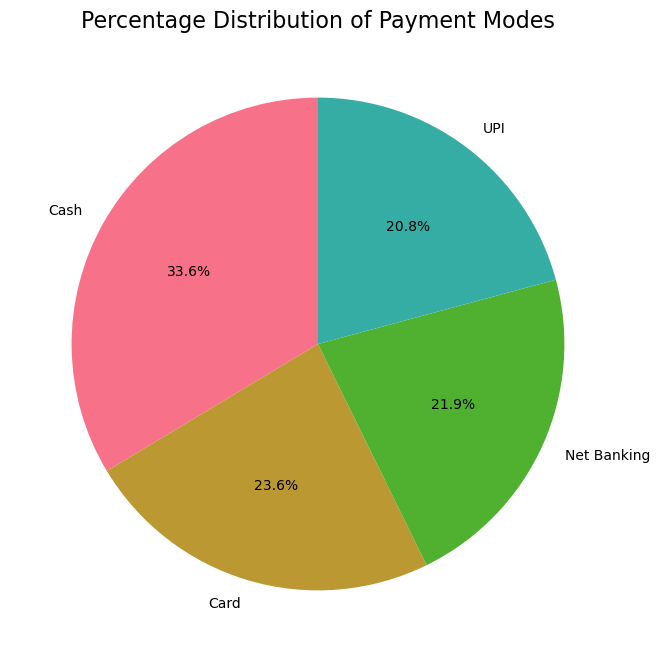

In [17]:
payment_counts = df['Payment_Mode'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(payment_counts, 
        labels=payment_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('husl'))
plt.title('Percentage Distribution of Payment Modes', fontsize=16)
plt.show()

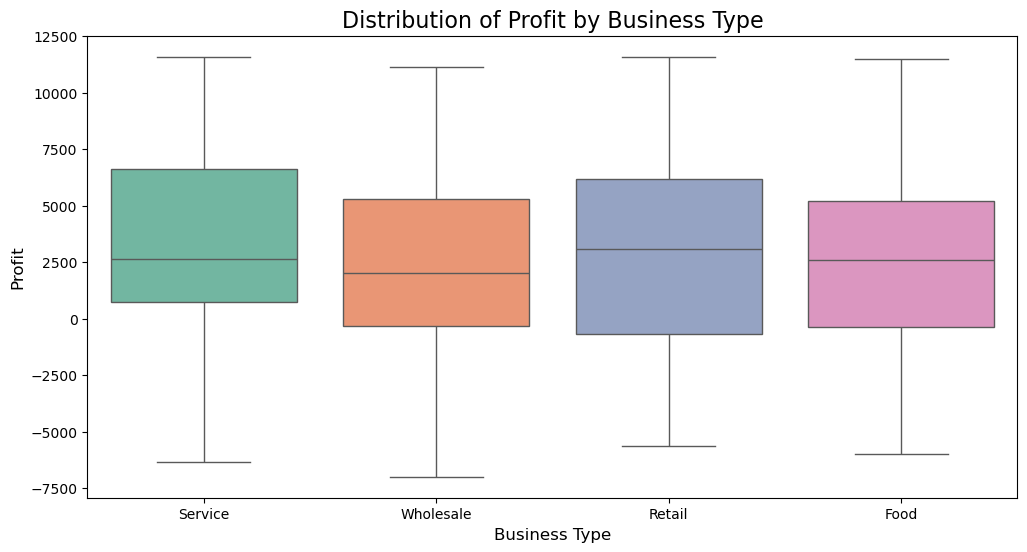

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Business_Type', y='Profit', palette='Set2')
plt.title('Distribution of Profit by Business Type', fontsize=16)
plt.xlabel('Business Type', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.show()

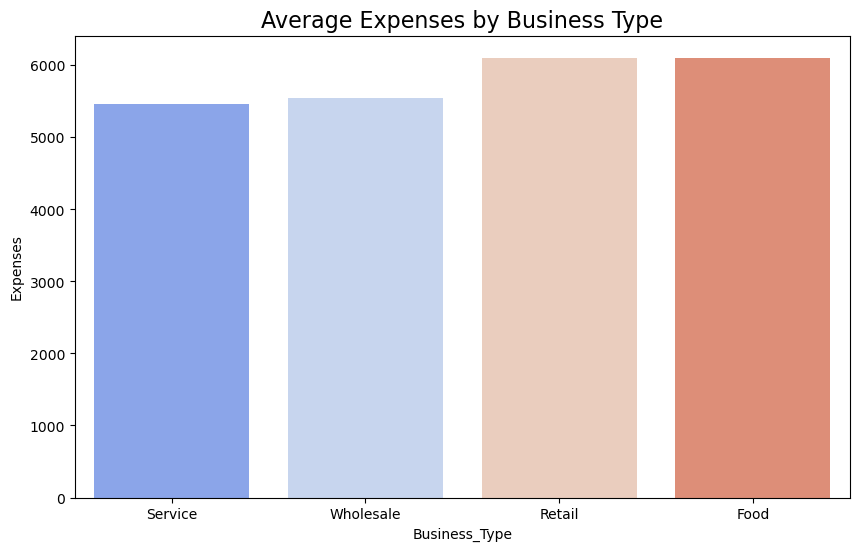

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Business_Type', y='Expenses', palette='coolwarm', errorbar=None)
plt.title('Average Expenses by Business Type', fontsize=16)
plt.show()

In [20]:
df = df.drop(columns=['Date'])
df

,Business_Type,Daily_Sales,Expenses,Customer_Count,Profit,Inventory,Payment_Mode
0,Service,4327,6878,75,-2551,152,UPI
1,Wholesale,10004,7303,33,2701,485,UPI
2,Retail,4931,1851,47,3080,398,UPI
3,Service,9777,2687,97,7090,320,Card
4,Service,2197,7833,149,-5636,156,Cash
...,...,...,...,...,...,...,...
346,Wholesale,11827,5777,173,6050,401,Card
347,Retail,9421,4900,188,4521,248,Cash
348,Retail,11949,7677,54,4272,357,Cash
349,Service,6452,7981,82,-1529,466,Net Banking


In [21]:
df.columns

Index(['Business_Type', 'Daily_Sales', 'Expenses', 'Customer_Count', 'Profit',
       'Inventory', 'Payment_Mode'],
      dtype='object')

In [22]:
x = df[['Daily_Sales','Inventory', 'Business_Type', 'Expenses', 'Customer_Count']]

In [23]:
x= df.drop('Profit',axis=1)
y= df['Profit']

In [24]:
x= pd.get_dummies(x)
x

,Daily_Sales,Expenses,Customer_Count,Inventory,Business_Type_Food,Business_Type_Retail,Business_Type_Service,Business_Type_Wholesale,Payment_Mode_Card,Payment_Mode_Cash,Payment_Mode_Net Banking,Payment_Mode_UPI
0,4327,6878,75,152,False,False,True,False,False,False,False,True
1,10004,7303,33,485,False,False,False,True,False,False,False,True
2,4931,1851,47,398,False,True,False,False,False,False,False,True
3,9777,2687,97,320,False,False,True,False,True,False,False,False
4,2197,7833,149,156,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
346,11827,5777,173,401,False,False,False,True,True,False,False,False
347,9421,4900,188,248,False,True,False,False,False,True,False,False
348,11949,7677,54,357,False,True,False,False,False,True,False,False
349,6452,7981,82,466,False,False,True,False,False,False,True,False


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8 , random_state=42) # test_sixe=0.2

In [26]:
LR =LinearRegression()
LR.fit(x_train, y_train)

LinearRegression()

In [27]:
y_predict = LR.predict(x_test)

In [28]:
r2= r2_score(y_test, y_predict)
r2*100

100.0

In [29]:
mae= mean_absolute_error( y_test, y_predict)
mae

2.0199428983918115e-12

In [30]:
mse= mean_squared_error(y_test, y_predict)
mse

6.167782629302591e-24

In [31]:
rmse = root_mean_squared_error(y_test, y_predict)
rmse

2.4835020896513438e-12

In [32]:
rmse = root_mean_squared_error(y_test, y_predict)
rmse

2.4835020896513438e-12

In [33]:
x

,Daily_Sales,Expenses,Customer_Count,Inventory,Business_Type_Food,Business_Type_Retail,Business_Type_Service,Business_Type_Wholesale,Payment_Mode_Card,Payment_Mode_Cash,Payment_Mode_Net Banking,Payment_Mode_UPI
0,4327,6878,75,152,False,False,True,False,False,False,False,True
1,10004,7303,33,485,False,False,False,True,False,False,False,True
2,4931,1851,47,398,False,True,False,False,False,False,False,True
3,9777,2687,97,320,False,False,True,False,True,False,False,False
4,2197,7833,149,156,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
346,11827,5777,173,401,False,False,False,True,True,False,False,False
347,9421,4900,188,248,False,True,False,False,False,True,False,False
348,11949,7677,54,357,False,True,False,False,False,True,False,False
349,6452,7981,82,466,False,False,True,False,False,False,True,False


In [41]:
cake_maker = pd.DataFrame([{
    'Daily_Sales':4000,
    'Expenses': 25000,
    'Customer_Count': 185,
    'Inventory' : 456,
    'Business_Type_Food' : 1,
    'Business_Type_Retail': 0,
    'Business_Type_Service' : 0,
    'Business_Type_Wholesale' : 0,	
    'Payment_Mode_Card' :0,
    'Payment_Mode_Cash' : 1,
    'Payment_Mode_Net Banking' : 0,
    'Payment_Mode_UPI' :1
}])

In [42]:
LR.predict(cake_maker)

array([-21000.])

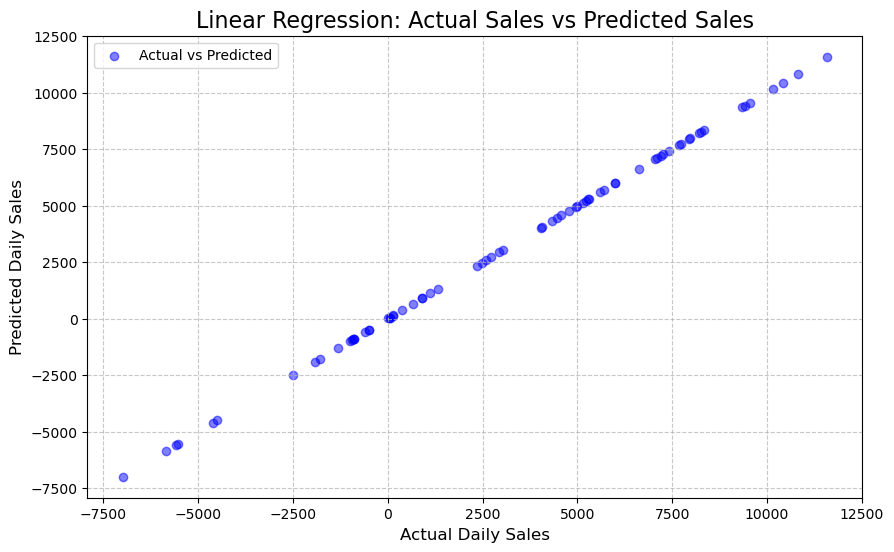

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, color='blue', alpha=0.5, label='Actual vs Predicted')
plt.title('Linear Regression: Actual Sales vs Predicted Sales', fontsize=16)
plt.xlabel('Actual Daily Sales', fontsize=12)
plt.ylabel('Predicted Daily Sales', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()